<a href="https://colab.research.google.com/github/rebahmalak/ml-projects/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction


## 1. Project Goal


The goal of this project is to predict a student's final score
using features such as study hours, sleep hours, attendance,
and previous score.

This project will use linear regression and the concepts learned
from Andrew Ng's Machine Learning course.

## 2. Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Load Dataset


In [2]:
X = np.array([
    [2, 6, 70, 55],
    [3, 7, 75, 60],
    [4, 7, 80, 65],
    [5, 8, 85, 70],
    [6, 7, 90, 72],
    [7, 8, 92, 78],
    [8, 8, 95, 85]
])

y = np.array([58, 64, 69, 76, 80, 86, 91])

## 4. Explore the Data


In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7, 4)
y shape: (7,)


In [4]:
print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
[[ 2  6 70 55]
 [ 3  7 75 60]
 [ 4  7 80 65]
 [ 5  8 85 70]
 [ 6  7 90 72]
 [ 7  8 92 78]
 [ 8  8 95 85]]

Target:
[58 64 69 76 80 86 91]


## 5. Visualize the Data


"Does this data make sense, and do the features appear to have a relationship with the target?" ( later , the model will try to learn these relationships mathematically )

### 5.1 Study Hours vs Final Score

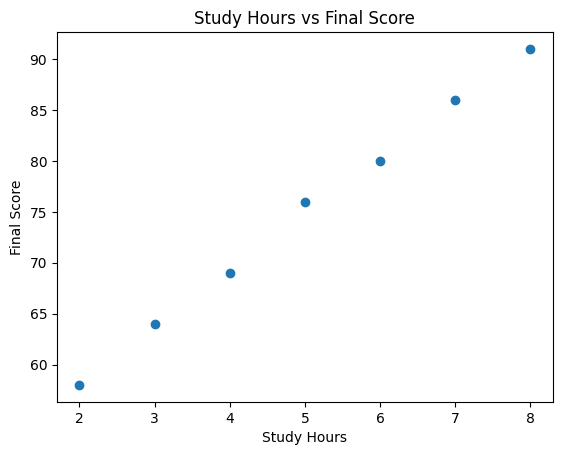

In [5]:
plt.scatter(X[:, 0], y)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

###5.2 Sleep Hours vs Final Score

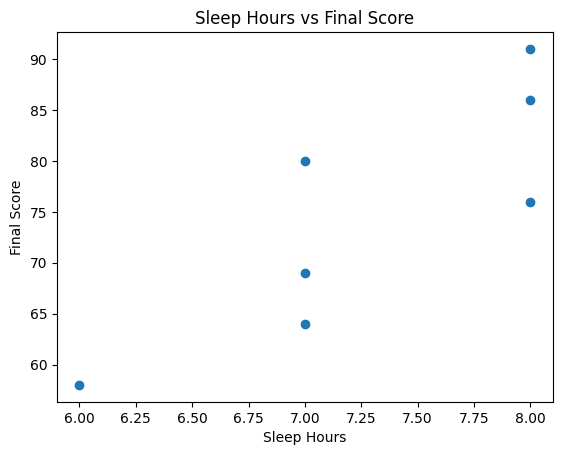

In [6]:
plt.scatter(X[:, 1], y)
plt.xlabel("Sleep Hours")
plt.ylabel("Final Score")
plt.title("Sleep Hours vs Final Score")
plt.show()

###5.3 Attendance vs Final Score

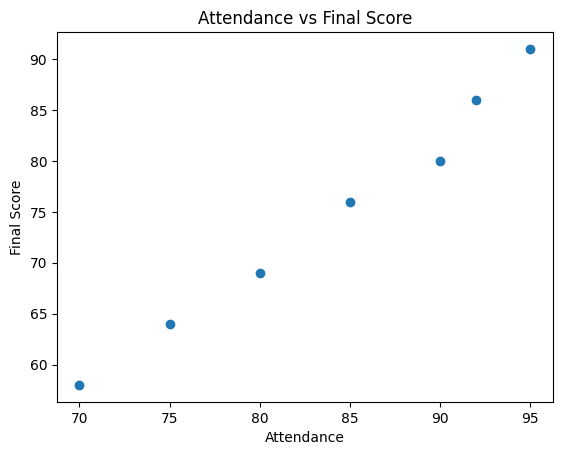

In [7]:
plt.scatter(X[:, 2], y)
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")
plt.show()

###5.4 Previous Score vs Final Score

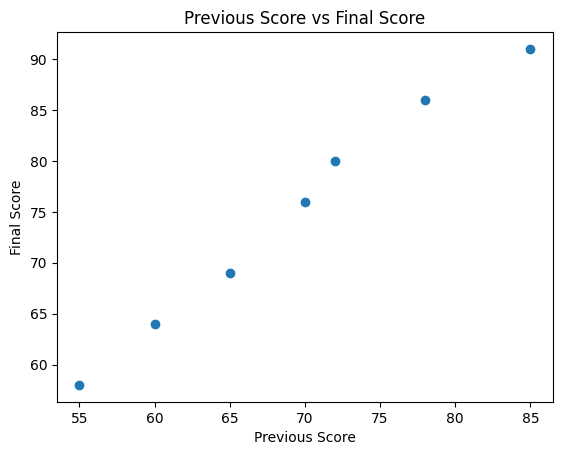

In [8]:
plt.scatter(X[:, 3], y)
plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")
plt.show()

## 6. Feature Scaling


### 6.1. Look at features range

In [9]:
print("Minimum values:", X.min(axis=0))
print("Maximum values:", X.max(axis=0))

Minimum values: [ 2  6 70 55]
Maximum values: [ 8  8 95 85]


###6.2. z-score normalization

####6.2.1 Calculate the mean and standard deviation

In [95]:
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

print("Mean:", mu)
print("Standard deviation:", sigma)

Mean: [ 5.          7.28571429 83.85714286 69.28571429]
Standard deviation: [2.         0.69985421 8.57618915 9.55755925]



####6.2.2 Normalize the features


In [12]:
X_norm = (X - mu) / sigma
print(X_norm)

[[-1.5        -1.83711731 -1.61576927 -1.49470319]
 [-1.         -0.40824829 -1.03275974 -0.97155707]
 [-0.5        -0.40824829 -0.44975021 -0.44841096]
 [ 0.          1.02062073  0.13325932  0.07473516]
 [ 0.5        -0.40824829  0.71626885  0.28399361]
 [ 1.          1.02062073  0.94947266  0.91176895]
 [ 1.5         1.02062073  1.29927838  1.64417351]]


####6.2.3 Verify the normalization

In [96]:
print("Normalized mean:", np.mean(X_norm, axis=0))
print("Normalized std:", np.std(X_norm, axis=0))

Normalized mean: [ 0.00000000e+00  1.26882631e-16 -5.39251183e-16 -6.66133815e-16]
Normalized std: [1. 1. 1. 1.]


## 7. Initialize Parameters


In [14]:
w = np.zeros(4)
b = 0

print("w:", w)
print("b:", b)

w: [0. 0. 0. 0.]
b: 0


## 8. Prediction


In [ ]:
def prediction (X,w,b ):
  p = np.dot(X,w)+b
  return p

## 9. Cost Function


In [62]:
def compute_cost(X, y, w, b):
  m = X.shape[0]
  error_sum = 0
  for i in range(m):
    f_wb_i = np.dot(X[i],w)+b
    error = (f_wb_i - y[i])**2
    error_sum = error_sum + error
  error_sum = error_sum /(2*m)
  return error_sum

### Calculate intial cost

In [64]:
initial_cost = compute_cost(X_norm, y,w,b)

print("Initial cost:", initial_cost)

Initial cost: 2862.4285714285716


## 10. Gradient Computation


In [65]:
 def compute_gradient(X, y, w, b):
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        prediction = np.dot(X[i], w) + b
        error = prediction - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i, j]

        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

## 11. Gradient Descent


In [66]:
def gradient_descent(w_init , b_init , X,y, alpha,num_iters):
  w = w_init.copy()
  b = b_init
  J_history = []
  for i in range(num_iters):
      dj_dw,dj_db = compute_gradient(X,y,w,b)
      w= w- alpha *dj_dw
      b= b- alpha *dj_db
      cost = compute_cost(X, y, w, b)
      J_history.append(cost)

  return w,b,J_history


## 12. Train the Model


##12.1 Choose the learning rate

In [67]:
alpha = 0.01
num_iters = 1000

##12.2 w_final , b_final

In [68]:
w_final, b_final, J_history = gradient_descent(
   w , b, X_norm , y , alpha , num_iters
)

In [69]:
print("Final w:", w_final)
print("Final b:", b_final)
print("Final cost:", J_history[-1])

Final w: [3.69287306 0.60144508 3.50411306 3.33932935]
Final b: 74.85391118090809
Final cost: 0.06687380611902166


## 13. Evaluate the Model

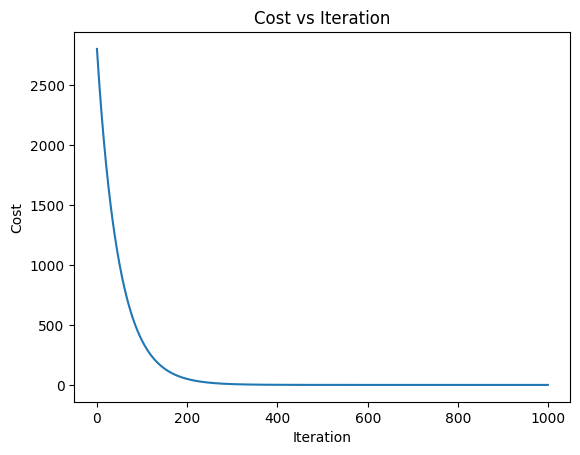

In [70]:
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.show()

# 14. Make Predictions

In [71]:
predictions = np.dot(X_norm, w_final) + b_final

print("Predictions:")
print(predictions)

Predictions:
[57.55653201 64.05224326 69.68856828 76.18427953 79.913044   85.53238791
 91.05032327]


In [72]:
for i in range(len(y)):
    print(f"Student {i+1}: Actual = {y[i]:.1f}, Predicted = {predictions[i]:.1f}")

Student 1: Actual = 58.0, Predicted = 57.6
Student 2: Actual = 64.0, Predicted = 64.1
Student 3: Actual = 69.0, Predicted = 69.7
Student 4: Actual = 76.0, Predicted = 76.2
Student 5: Actual = 80.0, Predicted = 79.9
Student 6: Actual = 86.0, Predicted = 85.5
Student 7: Actual = 91.0, Predicted = 91.1


## 15. Feature Engineering

##15.1 create new feature ( study_hours squared)

In [73]:
study_hours_squared = X[:, 0] ** 2
print(study_hours_squared)

[ 4  9 16 25 36 49 64]


In [75]:
X_engineered = np.c_[X, study_hours_squared]
print("New shape:", X_engineered.shape)

New shape: (7, 5)


## 15.2 scale again

In [76]:
mu_eng = np.mean(X_engineered, axis=0)
sigma_eng = np.std(X_engineered, axis=0)

X_eng_norm = (X_engineered - mu_eng) / sigma_eng

## 15.3 Train a new model

In [77]:
w_eng = np.zeros(5)
b_eng = 0
alpha = 0.01
num_iters = 1000

In [79]:
w_eng_final, b_eng_final, J_eng_history = gradient_descent(w_eng , b_eng , X_eng_norm , y ,alpha, num_iters)


##15.4 Check the new cost

In [80]:
print("Initial cost:", J_eng_history[0])
print("Final cost:", J_eng_history[-1])

Initial cost: 2801.182128124936
Final cost: 0.05449797458380796


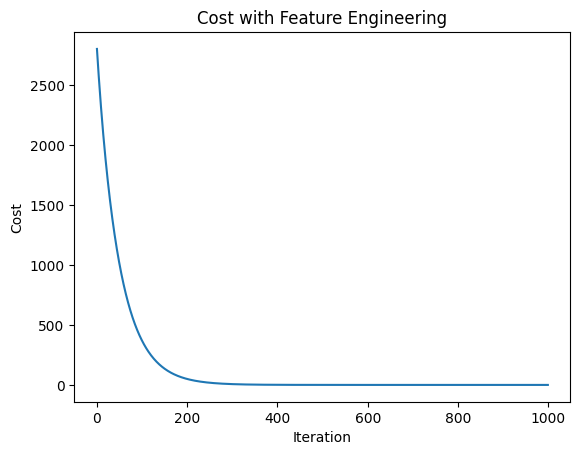

In [81]:
plt.plot(J_eng_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost with Feature Engineering")
plt.show()

# 16. Compare the two models

In [82]:
predictions_original = np.dot(X_norm, w_final) + b_final

In [83]:
predictions_engineered = np.dot(
    X_eng_norm,
    w_eng_final
) + b_eng_final

In [84]:
cost_original = compute_cost(
    X_norm,
    y,
    w_final,
    b_final
)

cost_engineered = compute_cost(
    X_eng_norm,
    y,
    w_eng_final,
    b_eng_final
)

print("Original model cost:", cost_original)
print("Engineered model cost:", cost_engineered)

Original model cost: 0.06687380611902166
Engineered model cost: 0.05449797458380796


In [85]:
for i in range(len(y)):
    print(
        f"Student {i+1}: "
        f"Actual={y[i]:.1f}, "
        f"Original={predictions_original[i]:.1f}, "
        f"Engineered={predictions_engineered[i]:.1f}"
    )

Student 1: Actual=58.0, Original=57.6, Engineered=58.0
Student 2: Actual=64.0, Original=64.1, Engineered=64.2
Student 3: Actual=69.0, Original=69.7, Engineered=69.2
Student 4: Actual=76.0, Original=76.2, Engineered=75.9
Student 5: Actual=80.0, Original=79.9, Engineered=79.4
Student 6: Actual=86.0, Original=85.5, Engineered=85.7
Student 7: Actual=91.0, Original=91.1, Engineered=91.5


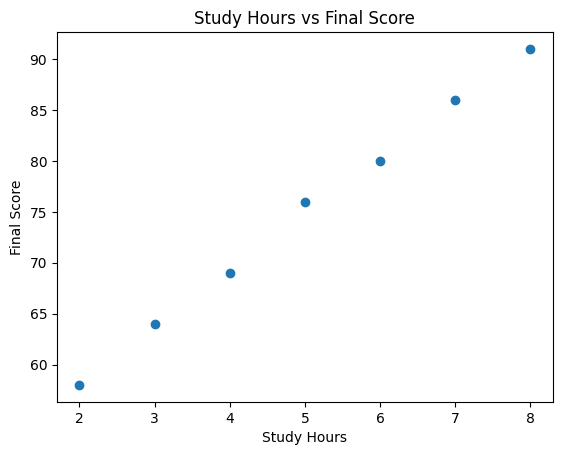

In [86]:
plt.scatter(X[:, 0], y)

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

#17. Test new student data

In [91]:
def predict_student(x_new):

    x_new = np.array([[x_new]])

    x_new_norm = (x_new - mu) / sigma

    prediction_original = (
        np.dot(x_new_norm, w_final) + b_final
    )
    return prediction_original.item()

In [94]:
new_student = [3,7,80,50]

original_prediction = predict_student(new_student)

print(f"New student input: {new_student}")
print(f"Original model prediction: {original_prediction:.2f}")


New student input: [3, 7, 80, 50]
Original model prediction: 62.60


#18. Conclusion

This project compared linear regression with a polynomial
regression model using feature engineering.

The polynomial model achieved a lower training cost on the
dataset, showing that the engineered features allowed the
model to better capture the relationship between the input
and target.

The project also demonstrates how the trained models can be
used to predict the target value for a new student.